# Switchback Power Formula Validation

**Goal**: Validate the closed-form variance formula for the ATE estimator via targeted OFAT sweeps.

**Formula**:
$$\text{Var}(\hat{\tau}) \approx \frac{4 \cdot \sigma_{total}^2}{J \cdot H} \left[ (S_{sp} + S_{time} + S_{int}) \left( \frac{1}{\bar{n}} + 1 + cv^2 \right) + \frac{S_{res}}{\bar{n}} \right]$$

**Strategy**: One-at-a-time (OFAT) sweeps, 1000 sims per regime.

## 0. Setup

In [0]:
# Importing sim_utils.py
%run ./sim_utils/sim_utils.py

Warning you are using the ipython `%run` line magic. To use the databricks `%run` cell magic make sure that the magic is at the very start of the cell.

sim_utils loaded.


In [0]:
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_style('whitegrid')
warnings.filterwarnings('ignore', category=FutureWarning)

RESULTS_DIR = './output/'
N_SIMS = 1000
print(f'sim_utils v{SIM_UTILS_VERSION} | N_SIMS={N_SIMS}')

sim_utils v2.1 | N_SIMS=1000


In [0]:
def theoretical_var(J, H, n_bar, cv, S_sp, S_time, S_int, S_res, total_std=1000.0):
    """Closed-form approximation of Var(tau_hat) for the switchback DGP."""
    cluster_component = (S_sp + S_time + S_int) * (1.0 / n_bar + 1.0 + cv**2)
    residual_component = S_res / n_bar
    return 4.0 * total_std**2 / (J * H) * (cluster_component + residual_component)

## 2. Baseline Configuration & Sweep Definitions

In [0]:
BASELINE = dict(
    n_sp=100,
    n_hours=168,
    mean_obs_per_sp_hour=20,
    cluster_size_cv=1.0,
    var_share_sp=0.10,
    var_share_hour=0.10,
    var_share_interaction=0.10,
    var_share_residual=0.70,
    # Fixed for v1
    grand_mean=2000.0,
    total_std=1000.0,
    treatment_prob=0.5,
    block_length=1,
    acf_lag1=0.3,        # formula predicts ACF has 0 effect when block_length=1
    tau=0.0,
    tau_sd=0.0,
    error_df=0.0,
    var_share_time_shock=0.0,
)

SWEEPS = {
    'S1_J':     ('n_sp',                [10, 20, 50, 100, 250, 500]),
    'S2_H':     ('n_hours',             [24, 48, 168, 336, 720]),
    'S3_CV':    ('cluster_size_cv',     [0.0, 0.5, 1.0, 2.0, 4.0]),
    'S4_nbar':  ('mean_obs_per_sp_hour',[2, 5, 10, 20, 50, 100]),
    'S5_shares': None,  # handled separately (multi-param)
    'S6_ACF':   ('acf_lag1',            [0.0, 0.3, 0.6, 0.9]),
    'S8_scale': ('total_std',           [500, 1000, 2000]),
}

# S5: Variance share sweep — vary S_res, keep within-macro proportions fixed
# (S_cl : S_time : S_int = 1:1:1 as in baseline; S_macro = 1 - S_res split equally)
S5_RES_VALUES = [0.25, 0.50, 0.70, 0.85]
S5_REGIMES = []
for s_res in S5_RES_VALUES:
    s_macro = round(1.0 - s_res, 4)
    s_each = round(s_macro / 3, 6)
    S5_REGIMES.append(dict(
        var_share_sp=s_each,
        var_share_hour=s_each,
        var_share_interaction=s_each,
        var_share_residual=s_res,  # set directly to avoid float arith errors
    ))

total_regimes = sum(len(v[1]) for k, v in SWEEPS.items() if v is not None)
total_regimes += len(S5_REGIMES)
print(f'Total regimes: {total_regimes}')
print(f'Total sims:    {total_regimes * N_SIMS:,}')

Total regimes: 33
Total sims:    33,000


## 3. Run Simulations

In [0]:
def build_params(overrides: dict) -> RegimeParams:
    """Create RegimeParams from BASELINE with selective overrides."""
    cfg = {**BASELINE, **overrides}
    return RegimeParams(**cfg)


def compute_theo_var_for_params(params):
    """Compute theoretical variance using the formula."""
    return theoretical_var(
        J=params.n_sp, H=params.n_hours,
        n_bar=params.mean_obs_per_sp_hour, cv=params.cluster_size_cv,
        S_sp=params.var_share_sp, S_time=params.var_share_hour,
        S_int=params.var_share_interaction, S_res=params.var_share_residual,
        total_std=params.total_std,
    )
def make_result_row(sweep_id, param_name, param_value, params, mc):
    """Build a single result dict from a completed MC run."""
    tau_hats = mc['ate_hat'].values
    emp_var = np.var(tau_hats, ddof=1)
    theo_var = compute_theo_var_for_params(params)
    return {
        'sweep_id': sweep_id,
        'param_varied': param_name,
        'param_value': param_value,
        **{k: getattr(params, k) for k in [
            'n_sp', 'n_hours', 'mean_obs_per_sp_hour', 'cluster_size_cv',
            'var_share_sp', 'var_share_hour', 'var_share_interaction',
            'var_share_residual', 'acf_lag1', 'total_std',
        ]},
        'S_time': params.var_share_hour,
        'empirical_var': emp_var,
        'empirical_se': np.sqrt(emp_var),
        'mean_sandwich_se': mc['se'].mean(),
        'theoretical_var': theo_var,
        'theoretical_se': np.sqrt(theo_var),
        'error_pct': abs(emp_var - theo_var) / theo_var * 100,
        'n_sims': len(tau_hats),
    }


def run_sweep(sweep_id, param_name, values, regime_offset=0):
    """Run an OFAT sweep: vary param_name over values, everything else at BASELINE."""
    results = []
    for idx, val in enumerate(values):
        regime_key = f'{sweep_id}_{param_name}_{val}'
        params = build_params({param_name: val})
        print(f'\n--- {regime_key} ---')
        mc = run_mc_for_method(
            regime_key, params, estimate_raw,
            n_sims=5000 if (sweep_id == 'S1_J' and val <= 20) or (sweep_id == 'S3_CV' and val >= 2.0) else N_SIMS, regime_index=regime_offset + idx,
            save_every=50, print_every=200, results_dir=RESULTS_DIR,
        )
        results.append(make_result_row(sweep_id, param_name, val, params, mc))
    return pd.DataFrame(results)

In [0]:
all_results = []
offset = 0

# --- S1-S4, S6, S8: standard OFAT sweeps ---
for sweep_id, spec in SWEEPS.items():
    if spec is None:
        continue
    param_name, values = spec
    df_sweep = run_sweep(sweep_id, param_name, values, regime_offset=offset)
    all_results.append(df_sweep)
    offset += len(values)

# --- S5: Variance share sweep (vary S_res, proportional within-macro split) ---
# Use 5k sims when S_macro is large (S_res <= 0.50): high macro variance => noisy MC
s5_results = []
for idx, overrides in enumerate(S5_REGIMES):
    s_res = overrides['var_share_residual']
    n_sims_s5 = 5000 if s_res <= 0.50 else N_SIMS
    regime_key = f'S5_shares_res_{s_res}'
    params = build_params(overrides)
    print(f'\n--- {regime_key} (n_sims={n_sims_s5}) ---')
    mc = run_mc_for_method(
        regime_key, params, estimate_raw,
        n_sims=n_sims_s5, regime_index=offset + idx,
        save_every=100, print_every=500, results_dir=RESULTS_DIR,
    )
    s5_results.append(make_result_row('S5_shares', 'var_share_residual', s_res, params, mc))
offset += len(S5_REGIMES)
all_results.append(pd.DataFrame(s5_results))

print(f'\n=== All sweeps complete. Total regimes: {offset} ===')


--- S1_J_n_sp_10 ---
[S1_J_n_sp_10/raw] Already complete (5000/5000). Skipping.

--- S1_J_n_sp_20 ---
[S1_J_n_sp_20/raw] Already complete (5000/5000). Skipping.

--- S1_J_n_sp_50 ---
[S1_J_n_sp_50/raw] Already complete (1000/1000). Skipping.

--- S1_J_n_sp_100 ---
[S1_J_n_sp_100/raw] Already complete (1000/1000). Skipping.

--- S1_J_n_sp_250 ---
[S1_J_n_sp_250/raw] Already complete (1000/1000). Skipping.

--- S1_J_n_sp_500 ---
[S1_J_n_sp_500/raw] Already complete (1000/1000). Skipping.

--- S2_H_n_hours_24 ---
[S2_H_n_hours_24/raw] Already complete (1000/1000). Skipping.

--- S2_H_n_hours_48 ---
[S2_H_n_hours_48/raw] Already complete (1000/1000). Skipping.

--- S2_H_n_hours_168 ---
[S2_H_n_hours_168/raw] Already complete (1000/1000). Skipping.

--- S2_H_n_hours_336 ---
[S2_H_n_hours_336/raw] Already complete (1000/1000). Skipping.

--- S2_H_n_hours_720 ---
[S2_H_n_hours_720/raw] Already complete (1000/1000). Skipping.

--- S3_CV_cluster_size_cv_0.0 ---
[S3_CV_cluster_size_cv_0.0/raw] 

## 4. Collect & Save Results

In [0]:
results = pd.concat(all_results, ignore_index=True)
results.to_csv(os.path.join(RESULTS_DIR, 'validation_results.csv'), index=False)
print(f'Saved {len(results)} regimes to {RESULTS_DIR}validation_results.csv')
results[['sweep_id', 'param_varied', 'param_value',          'empirical_var', 'theoretical_var', 'error_pct']].round(4)

Saved 33 regimes to ./output/validation_results.csv


,sweep_id,param_varied,param_value,empirical_var,theoretical_var,error_pct
0,S1_J,n_sp,10.00,1264.5019,1547.6190,18.2937
1,S1_J,n_sp,20.00,663.3242,773.8095,14.2781
2,S1_J,n_sp,50.00,305.0557,309.5238,1.4436
3,S1_J,n_sp,100.00,165.6330,154.7619,7.0244
4,S1_J,n_sp,250.00,64.0432,61.9048,3.4544
5,S1_J,n_sp,500.00,33.0179,30.9524,6.6731
6,S2_H,n_hours,24.00,1067.0435,1083.3333,1.5037
7,S2_H,n_hours,48.00,536.3436,541.6667,0.9827
8,S2_H,n_hours,168.00,158.9816,154.7619,2.7266
9,S2_H,n_hours,336.00,81.1613,77.3810,4.8854


## 6. Paper Visuals (Danger Zone & Final Artifacts)

In [0]:
import os

PAPER_DIR = os.path.join(RESULTS_DIR, 'paper', 'switchback_power')
os.makedirs(PAPER_DIR, exist_ok=True)
print(f'Paper visuals will be saved to: {PAPER_DIR}')

Paper visuals will be saved to: ./output/paper/switchback_power


In [0]:
# Categorize regimes
# Boundary regime: cv >= 2.0 or J <= 10
results['zone'] = 'Interior'
results.loc[(results['cluster_size_cv'] >= 2.0) | (results['n_sp'] <= 10), 'zone'] = 'Boundary'
# Interaction sweeps with extreme parameters
results.loc[results['sweep_id'].str.startswith('S7'), 'zone'] = 'Interaction/Boundary'

zone_colors = {'Interior': 'steelblue', 'Boundary': 'coral', 'Interaction/Boundary': 'darkred'}

print(results['zone'].value_counts())

Interior    30
Boundary     3
Name: zone, dtype: int64


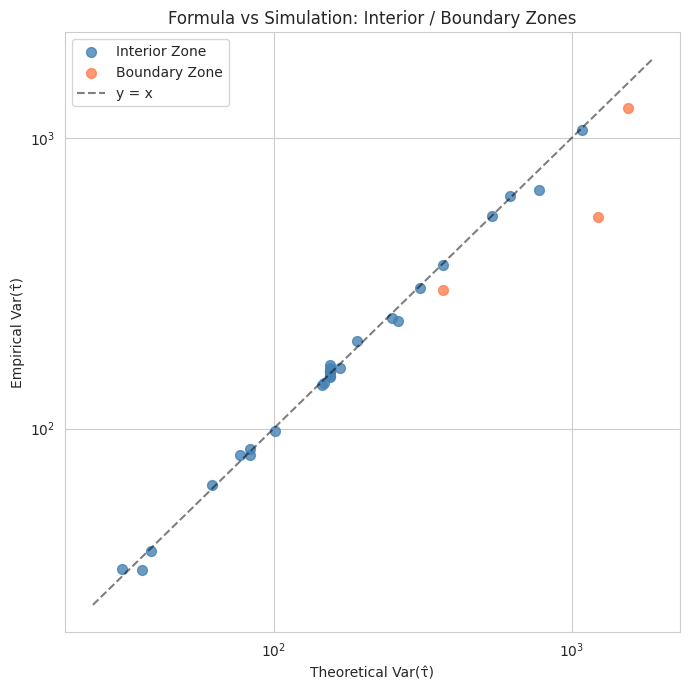

In [0]:
fig, ax = plt.subplots(figsize=(7, 7))

for zone in ['Interior', 'Boundary', 'Interaction/Boundary']:
    sub = results[results['zone'] == zone]
    if len(sub) > 0:
        ax.scatter(sub['theoretical_var'], sub['empirical_var'], 
                   label=f'{zone} Zone', s=50, alpha=0.8, color=zone_colors[zone])

lims = [min(results['theoretical_var'].min(), results['empirical_var'].min()) * 0.8,
        max(results['theoretical_var'].max(), results['empirical_var'].max()) * 1.2]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Theoretical Var(τ̂)'); ax.set_ylabel('Empirical Var(τ̂)')
ax.set_title('Formula vs Simulation: Interior / Boundary Zones')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, 'scatter_theo_vs_emp_zones.png'), dpi=150)
plt.show()

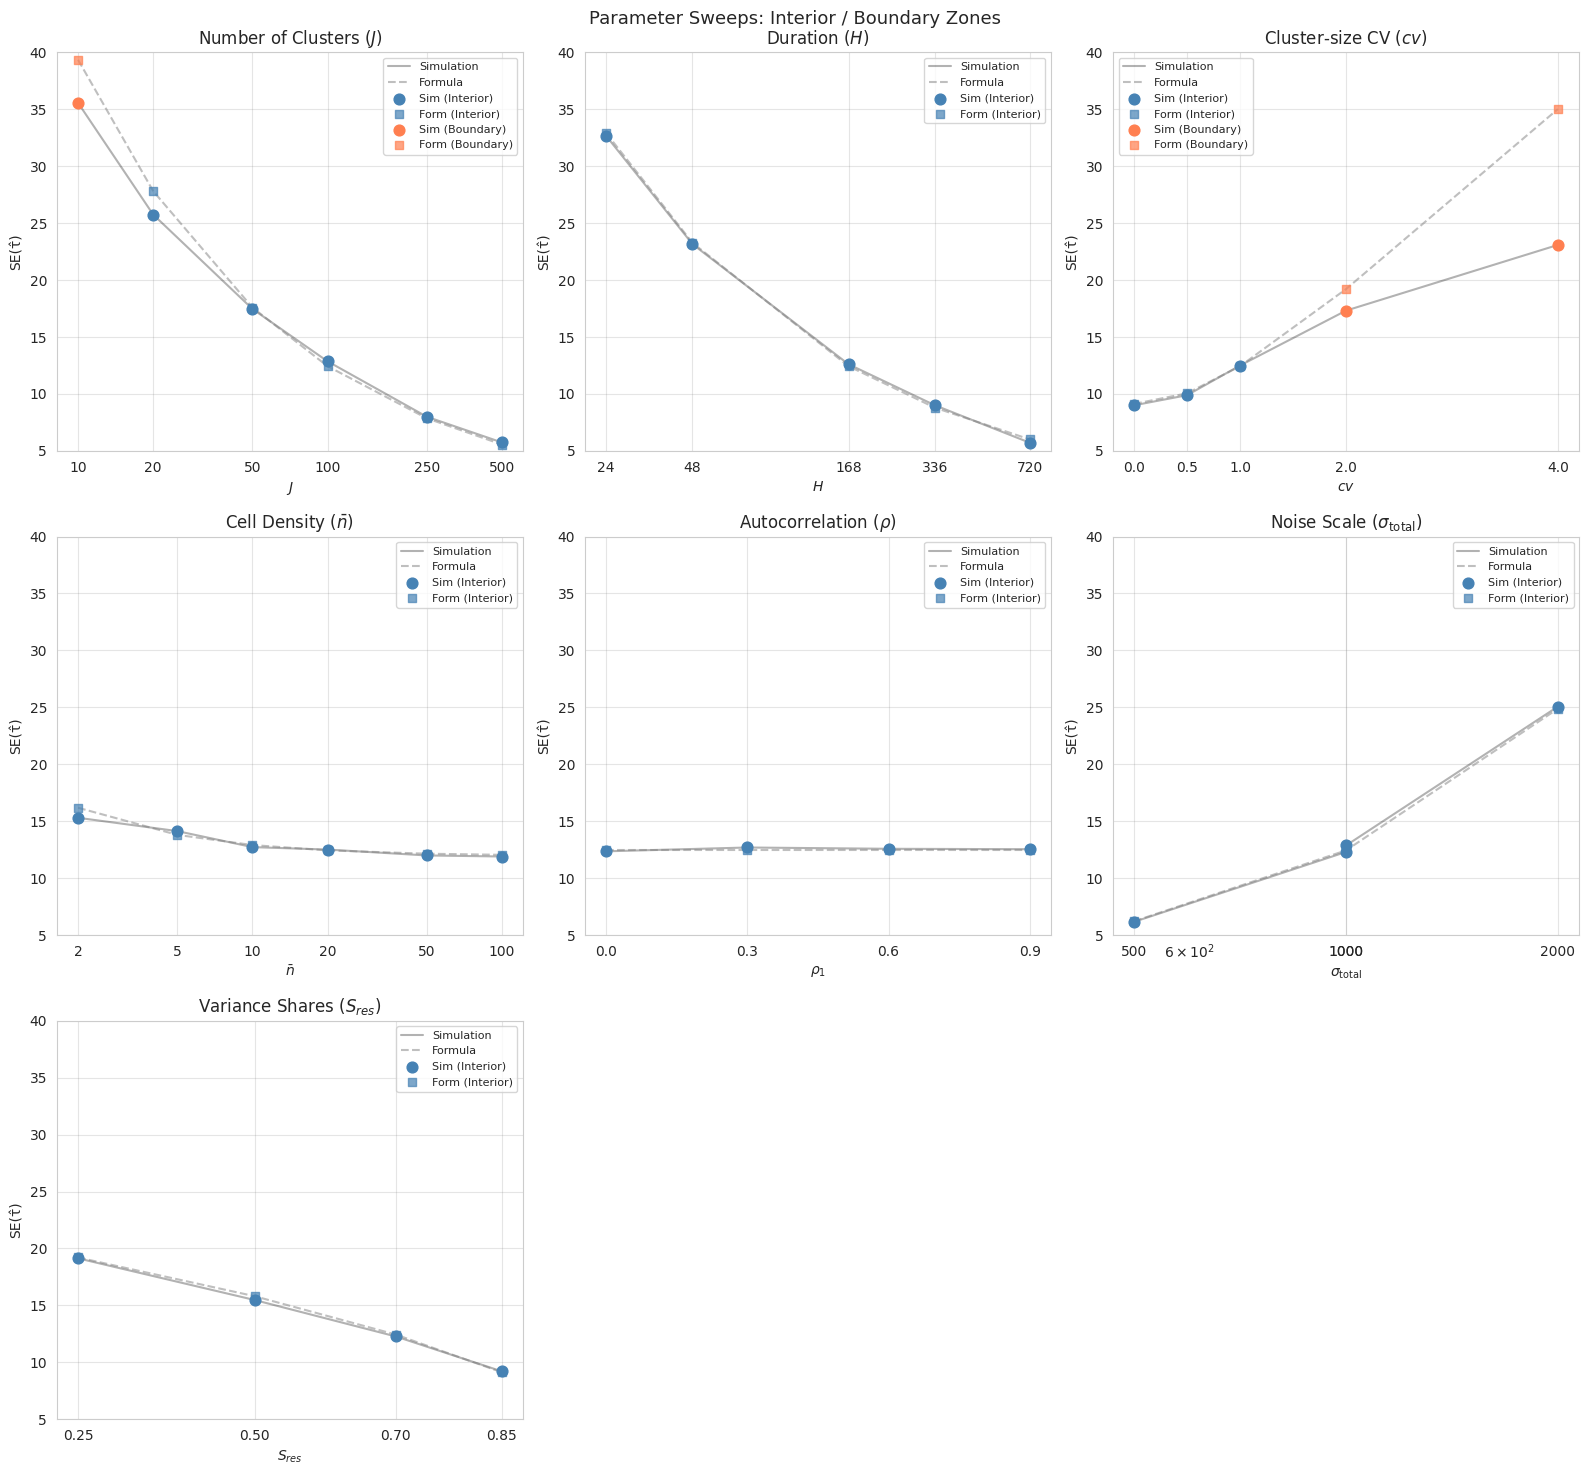

In [0]:
import matplotlib.ticker
# Build results_plot: add the baseline point as a free S8 data point
baseline_row = results[
    (results['n_sp'] == BASELINE['n_sp']) &
    (results['n_hours'] == BASELINE['n_hours']) &
    (results['cluster_size_cv'] == BASELINE['cluster_size_cv']) &
    (results['mean_obs_per_sp_hour'] == BASELINE['mean_obs_per_sp_hour']) &
    (results['total_std'] == BASELINE['total_std']) &
    (results['var_share_sp'] == BASELINE['var_share_sp'])
].head(1)

if not baseline_row.empty:
    free_pt = baseline_row.iloc[0].to_dict()
    free_pt.update(sweep_id='S8_scale', param_varied='total_std', param_value=1000.0)
    results_plot = pd.concat([results, pd.DataFrame([free_pt])], ignore_index=True)
else:
    results_plot = results.copy()

ofat_sweeps = results_plot[~results_plot['sweep_id'].str.startswith('S7')].copy()

# Ensure zone categorization applies to the results_plot df too (which has the S8 baseline free point)
ofat_sweeps['zone'] = 'Interior'
ofat_sweeps.loc[(ofat_sweeps['cluster_size_cv'] >= 2.0) | (ofat_sweeps['n_sp'] <= 10), 'zone'] = 'Boundary'

sweep_ids = ofat_sweeps['sweep_id'].unique()
n_panels = len(sweep_ids)
nrows = (n_panels + 2) // 3

fig, axes = plt.subplots(nrows, 3, figsize=(16, 5 * nrows))
axes = axes.ravel()

PARAM_LABELS = {
    'n_sp': '$J$',
    'n_hours': '$H$',
    'cluster_size_cv': '$cv$',
    'mean_obs_per_sp_hour': r'$\bar{n}$',
    'var_share_sp': '$S_{cl}$',
    'var_share_residual': '$S_{res}$',
    'acf_lag1': r'$\rho_1$',
    'total_std': r'$\sigma_{\mathrm{total}}$',
}
SWEEP_LABELS = {
    'S1_J':      'Number of Clusters ($J$)',
    'S2_H':      'Duration ($H$)',
    'S3_CV':     'Cluster-size CV ($cv$)',
    'S4_nbar':   r'Cell Density ($\bar{n}$)',
    'S5_shares': 'Variance Shares ($S_{res}$)',
    'S6_ACF':    r'Autocorrelation ($\rho$)',
    'S8_scale':  r'Noise Scale ($\sigma_{\mathrm{total}}$)',
}
for i, sid in enumerate(sweep_ids):
    ax = axes[i]
    sub = ofat_sweeps[ofat_sweeps['sweep_id'] == sid].sort_values('param_value')
    pname = sub['param_varied'].iloc[0]
    x = sub['param_value'].astype(float)

    # Plot base lines
    ax.plot(x, sub['empirical_se'], '-', color='black', label='Simulation', alpha=0.3)
    ax.plot(x, sub['theoretical_se'], '--', color='gray', label='Formula', alpha=0.5)
    
    # Highlight points by zone
    for zone in ['Interior', 'Boundary']:
        zone_mask = sub['zone'] == zone
        if zone_mask.any():
            ax.scatter(x[zone_mask], sub.loc[zone_mask, 'empirical_se'], 
                       color=zone_colors[zone], s=60, zorder=5, label=f'Sim ({zone})', marker='o')
            ax.scatter(x[zone_mask], sub.loc[zone_mask, 'theoretical_se'], 
                       color=zone_colors[zone], s=40, zorder=4, label=f'Form ({zone})', marker='s', alpha=0.7)

    ax.set_xlabel(PARAM_LABELS.get(pname, pname))
    ax.set_ylabel('SE(τ̂)')
    ax.set_ylim(5, 40)
    ax.set_title(SWEEP_LABELS.get(sid, sid))
    
    # Handle legends without dupes
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8)
    
    if pname in ('n_sp', 'n_hours', 'mean_obs_per_sp_hour', 'total_std'):
        ax.set_xscale('log')
    ax.set_xticks(x)
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid(True, which='major', color='gray', linestyle='-', alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Parameter Sweeps: Interior / Boundary Zones', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, 'ofat_sweeps_zones.png'), dpi=150)
plt.show()

In [0]:
zone_summary = results.groupby(['sweep_id', 'zone']).agg(
    n_regimes=('error_pct', 'count'),
    mean_error_pct=('error_pct', 'mean'),
    max_error_pct=('error_pct', 'max'),
).round(2).reset_index()

zone_summary = zone_summary.sort_values(['sweep_id', 'zone'])

SWEEP_LABELS = {
    'S1_J':      'Clusters (J)',
    'S2_H':      'Duration (H)',
    'S3_CV':     'Cluster-size CV',
    'S4_nbar':   'Cell Density (nbar)',
    'S5_shares': 'Variance Shares (S_res)',
    'S6_ACF':    'Autocorrelation',
    'S8_scale':  'Noise Scale',
}
zone_summary_display = zone_summary.copy()
zone_summary_display['sweep_id'] = zone_summary_display['sweep_id'].map(lambda x: SWEEP_LABELS.get(x, x))
zone_summary_display = zone_summary_display.rename(columns={'sweep_id': 'Parameter', 'zone': 'Zone', 'n_regimes': 'N', 'mean_error_pct': 'Mean Error %', 'max_error_pct': 'Max Error %'})
print('=== Validation Summary by Sweep and Zone ===')
display(zone_summary_display)

zone_summary.to_csv(os.path.join(PAPER_DIR, 'zone_summary_table.csv'), index=False)

=== Validation Summary by Sweep and Zone ===


Parameter,Zone,N,Mean Error %,Max Error %
Clusters (J),Boundary,1,18.29,18.29
Clusters (J),Interior,5,6.57,14.28
Duration (H),Interior,5,3.92,9.51
Cluster-size CV,Boundary,2,37.62,56.52
Cluster-size CV,Interior,3,2.29,3.27
Cell Density (nbar),Interior,6,4.06,10.58
Variance Shares (S_res),Interior,4,2.37,4.19
Autocorrelation,Interior,4,2.35,4.13
Noise Scale,Interior,3,1.78,2.19
